# CSE 4/587 Fall 2024
# ****` Homework 2 - Spark`****
## Author: Taran Mamidala

---

To start this assignment, I set up the environment by importing the required libraries.



In [181]:
# !pip install pyspark==3.0.1 findspark
# !pip install pyspark pyngrok

In [192]:
import string

from pyngrok import ngrok
from pyspark.sql import SparkSession

#  ngrok auth token
# !ngrok config add-authtoken <NGROK_AUTH_TOKEN>
# !ngrok config add-authtoken <NGROK_AUTH_TOKEN>
# !ngrok config add-authtoken <NGROK_AUTH_TOKEN>


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


Now, I created a Spark session that will allow me to work with distributed data in this notebook.

In [228]:

# Initialize Spark with WebUI enabled (default port is 4040)
spark = SparkSession.builder \
    .appName("WordCountProgram") \
    .config("spark.ui.port", "4040") \
    .getOrCreate()

To understand how Spark processed the word count job, I accessed the Spark WebUI and observed Directed Acyclic Graph (DAG).

In [229]:
public_url = ngrok.connect(4040)
print("Spark UI available at:", public_url)


Spark UI available at: NgrokTunnel: "https://e80f-34-138-205-238.ngrok-free.app" -> "http://localhost:4040"


In [196]:

print("Spark version:", spark.version)

Spark version: 3.0.1


## Part 1: Implement and Analyze Word Count

In this, I implemented a Word Count program that reads two text files, counts the occurrences of each word, and outputs a key-value list of words and their counts in `output_1.txt`.

In [230]:

sc = spark.sparkContext

 Then, I loaded the two text files and combined them into one RDD.

In [208]:

text_rdd = sc.textFile("book1.txt").union(sc.textFile("book2.txt"))


Here, I ran a simple word count to see how many times each word appeared in the text. and I saved this initial result as output_1.txt


In [209]:
# Basic word count program: Split lines into words, map each word to (word, 1), Count occurrences of each word, and sort in descending order
word_counts_rdd = text_rdd.flatMap(lambda line: line.split()) \
    .filter(lambda word: word.isalpha()) \
    .map(lambda word: (word, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .sortBy(lambda x: x[1], ascending=False)

In [190]:

sample_words = word_counts_rdd.take(10)
print(sample_words)


[('the', 9608), ('of', 7375), ('and', 5647), ('to', 5349), ('a', 3888), ('in', 3303), ('I', 2886), ('is', 1948), ('that', 1939), ('as', 1569)]


Finally, I saved the word counts to output_1.txt and printed the top 25 words.

In [210]:

word_counts_rdd.saveAsTextFile("output_1.txt")

In [33]:
import glob

file_paths = glob.glob('output_1.txt/part-*')

with open('output__1.txt', 'w') as outfile:
    for file_path in file_paths:
        with open(file_path, 'r') as infile:
            outfile.write(infile.read())


In [34]:

top_25_words_basic = word_counts_rdd.take(25)
print("Top 25 Words in Basic Word Count (output_1.txt):")
for word, count in top_25_words_basic:
    print(f"{word}: {count}")

Top 25 Words in Basic Word Count (output_1.txt):
the: 9608
of: 7375
and: 5647
to: 5349
a: 3888
in: 3303
I: 2886
is: 1948
that: 1939
as: 1569
my: 1549
with: 1443
was: 1326
or: 1306
for: 1269
by: 1242
be: 1176
it: 1118
which: 1103
his: 1021
not: 1021
are: 902
their: 863
at: 857
he: 852


In [20]:

!head output__1.txt

('Price', 1)
('GULLIVER’S', 1)
('st.', 1)
('[_First', 1)
('[_As', 1)
('edition_.]', 1)
('Lemuel', 1)
('mother’s', 1)
('Oxfordshire;', 1)
('churchyard', 1)



In this basic version, It counts every word as it appears, without making any adjustments for things like punctuation or case

## Extended Word Count Program

In addition to the basic word count, I extended the program by making the word count case-insensitive, removing punctuation, filtering out stop words, and ensuring that the results were sorted in descending order by count.

In [231]:

text_rdd = sc.textFile("book1.txt").union(sc.textFile("book2.txt"))


I filtered out common stop words like "the," "is," "in," etc., which don’t contribute much to the overall understanding of the text. Using Spark’s filter, I excluded these words from the final count.

In [232]:

stop_words = {
    "the", "is", "in", "and", "a", "to", "of", "it", "i", "my", "or", "was",
    "which", "be", "he", "his", "not", "me", "they", "but", "are", "their",
    "had", "so", "an", "have", "all", "upon", "them", "we", "were", "some", "one",
    "with", "for", "as", "by", "on", "at", "this", "that", "you", "your", "from",
    "do", "does", "did", "what", "when", "where", "who", "whom", "can", "could",
    "would", "will", "just", "there", "if", "than", "then"
}  # My stop words

- I converted all words to lowercase to ensure that the word count is case-insensitive.
- Removing Punctuation: Using translate, I removed any punctuation from the text.
- Filtering Stop Words: Common stop words were filtered out to focus on more meaningful terms.
- Mapping and Reducing: I mapped each word to a (word, 1) pair and then reduced by key to count occurrences of each word.
- The output was sorted by word count in descending order to identify the most common words.

In [233]:
# Process each line: lowercase, remove punctuation, filter stop words, map each word to (word, 1)
extended_word_counts_rdd = (text_rdd
    .flatMap(lambda line: line.lower().translate(str.maketrans("", "", string.punctuation)).split())
    .filter(lambda word: word.isalpha())  # Keep only words with alphabetic characters
    .filter(lambda word: word not in stop_words)
    .map(lambda word: (word, 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[1], ascending=False))

In [234]:

extended_word_counts_rdd.saveAsTextFile("output_1__extended.txt")

In [25]:
import glob

file_paths = glob.glob('output_1_extended.txt/part-*')

with open('output__1_extended.txt', 'w') as outfile:
    for file_path in file_paths:
        with open(file_path, 'r') as infile:
            outfile.write(infile.read())


 I extracted the top 25 most common words from the extended word count.

In [26]:
# Displaying the top 25 most common words and their counts in the extended word count
top_25_words_extended = extended_word_counts_rdd.take(25)
print("Top 25 most common words in Extended Word Count (output_1_extended.txt):")
for word, count in top_25_words_extended:
    print(f"{word}: {count}")

Top 25 most common words in Extended Word Count (output_1_extended.txt):
into: 462
any: 446
other: 430
him: 376
out: 367
more: 360
no: 353
very: 353
sidenote: 347
great: 341
may: 337
about: 330
up: 316
these: 313
our: 310
its: 303
two: 299
should: 292
own: 288
only: 279
such: 276
made: 271
been: 271
those: 269
much: 265


In [35]:

!head output__1_extended.txt

('mother’s', 1)
('churchyard', 1)
('banbury', 1)
('storms', 1)
('dampier', 1)
('retirement', 1)
('pleaders', 1)
('nobility’s', 1)
('disgracers', 1)
('reformations', 1)


---

## Part 2: Implement and Analyze Dijkstra’s Shortest Path Algorithm

For Part 2, I implemented Dijkstra’s Shortest Path algorithm. The program reads edge data from question2_1.txt and question2_2.txt, calculates the shortest path from the start node to all other nodes, and saves the output to output_2.txt.



In [83]:
# !pip install pyspark pyngrok
# !ngrok config add-authtoken <NGROK_AUTH_TOKEN>


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [84]:
spark.stop()
from pyspark.sql import SparkSession

# Initialize Spark with WebUI enabled (default port is 4040)
spark = SparkSession.builder \
    .appName("DijkstraPathAlgorithm") \
    .config("spark.ui.port", "4040") \
    .getOrCreate()
sc = spark.sparkContext

In [85]:
!pkill -f ngrok
# Import ngrok and start tunnel
from pyngrok import ngrok

public_url = ngrok.connect(4040)
print("Spark WebUI Link:", public_url)

Spark WebUI Link: NgrokTunnel: "https://b97b-34-138-205-238.ngrok-free.app" -> "http://localhost:4040"


In [86]:

!head question2_1.txt

0, 1, 8
0, 2, 10
0, 3, 1
0, 4, 3
0, 5, 6
0, 6, 3
0, 7, 8
0, 8, 4
0, 9, 2
0, 10, 7


In [87]:
!head question2_2.txt

0, 1, 1
0, 2, 2
0, 3, 2
0, 4, 4
0, 5, 7
0, 6, 1
0, 7, 10
0, 8, 2
0, 9, 9
0, 10, 7


I started by loading and combining the two files into an RDD, ensuring each line followed the format source, destination, weight.

I loaded the graph data needed for Dijkstra’s algorithm. Each line in the text files represents a link between nodes, along with a weight value. These weights are important because they’ll help determine the shortest paths between nodes

In [88]:
# Load and parse the edges
edges_rdd = sc.textFile("question2_1.txt").union(sc.textFile("question2_2.txt")) \
    .map(lambda line: tuple(map(int, line.split(',')))) \
    .map(lambda x: (x[0], (x[1], x[2])))

In [89]:
# Persist edges RDD in memory to avoid reloading and recomputation
edges_rdd = edges_rdd.persist()

# Display a sample of the loaded edges
sample_edges = edges_rdd.take(5)
print("Sample edges from graph data:", sample_edges)

Sample edges from graph data: [(0, (1, 8)), (0, (2, 10)), (0, (3, 1)), (0, (4, 3)), (0, (5, 6))]


I set the start node's distance to 0, with all other nodes initialized to infinity. Then, I defined a function to update distances iteratively.

Using Dijkstra’s algorithm, I calculated the shortest path from the initial node to every other node in the graph.

In [90]:
def dijkstra_algorithm(edges_rdd, start_node=0):
   
    distances_rdd = sc.parallelize([(start_node, 0)])  

    def relax_edges(distances_rdd):

        joined_rdd = distances_rdd.join(edges_rdd)

        updated_distances_rdd = joined_rdd.map(lambda x: (x[1][1][0], x[1][0] + x[1][1][1])) \
            .reduceByKey(min)
        return updated_distances_rdd

    old_distances_rdd = None
    while old_distances_rdd is None or old_distances_rdd.join(distances_rdd).filter(lambda x: x[1][0] != x[1][1]).count() > 0:
        old_distances_rdd = distances_rdd

        distances_rdd = distances_rdd.union(relax_edges(distances_rdd)).reduceByKey(min)

    return distances_rdd

After calculating distances, I saved the results to output_2.txt and identified the nodes with the greatest and least distance from the start.

In [91]:

start_node = 0
shortest_paths_rdd = dijkstra_algorithm(edges_rdd, start_node=start_node)

In [92]:

shortest_paths_rdd.saveAsTextFile("output_2.txt")

In [79]:
import glob

file_paths = glob.glob('output_2.txt/part-*')

with open('output__2.txt', 'w') as outfile:
    for file_path in file_paths:
        with open(file_path, 'r') as infile:
            outfile.write(infile.read())


In [80]:

shortest_paths = shortest_paths_rdd.collect()  
for node, distance in shortest_paths:
    print(f"Node {node}: Distance {distance}")



Node 0: Distance 0
Node 24: Distance 3
Node 48: Distance 5
Node 72: Distance 3
Node 96: Distance 7
Node 8: Distance 2
Node 32: Distance 1
Node 56: Distance 4
Node 80: Distance 1
Node 16: Distance 2
Node 40: Distance 1
Node 64: Distance 2
Node 88: Distance 8
Node 1: Distance 1
Node 25: Distance 1
Node 49: Distance 2
Node 73: Distance 3
Node 97: Distance 3
Node 9: Distance 2
Node 33: Distance 8
Node 57: Distance 2
Node 81: Distance 2
Node 17: Distance 7
Node 41: Distance 1
Node 65: Distance 1
Node 89: Distance 2
Node 18: Distance 2
Node 42: Distance 3
Node 66: Distance 2
Node 90: Distance 2
Node 2: Distance 2
Node 26: Distance 5
Node 50: Distance 2
Node 74: Distance 8
Node 98: Distance 7
Node 10: Distance 7
Node 34: Distance 2
Node 58: Distance 4
Node 82: Distance 1
Node 19: Distance 1
Node 43: Distance 6
Node 67: Distance 2
Node 91: Distance 2
Node 3: Distance 1
Node 27: Distance 4
Node 51: Distance 2
Node 75: Distance 2
Node 99: Distance 7
Node 11: Distance 1
Node 35: Distance 6
Node 5

In [81]:

!head output__2.txt


(6, 1)
(30, 2)
(54, 5)
(78, 10)
(14, 3)
(38, 4)
(62, 2)
(86, 7)
(22, 2)
(46, 6)


After running the algorithm, I took a closer look at the results to find the nodes that are the farthest and nearest to the starting point.

In [82]:

distances = shortest_paths_rdd.collectAsMap()

farthest_node = max(distances, key=distances.get)

nearest_node = min((node for node in distances if distances[node] > 0), key=distances.get)

print(f"Node with greatest distance: {farthest_node} - Distance: {distances[farthest_node]}")
print(f"Node with shortest non-zero distance: {nearest_node} - Distance: {distances[nearest_node]}")


Node with greatest distance: 78 - Distance: 10
Node with shortest non-zero distance: 32 - Distance: 1


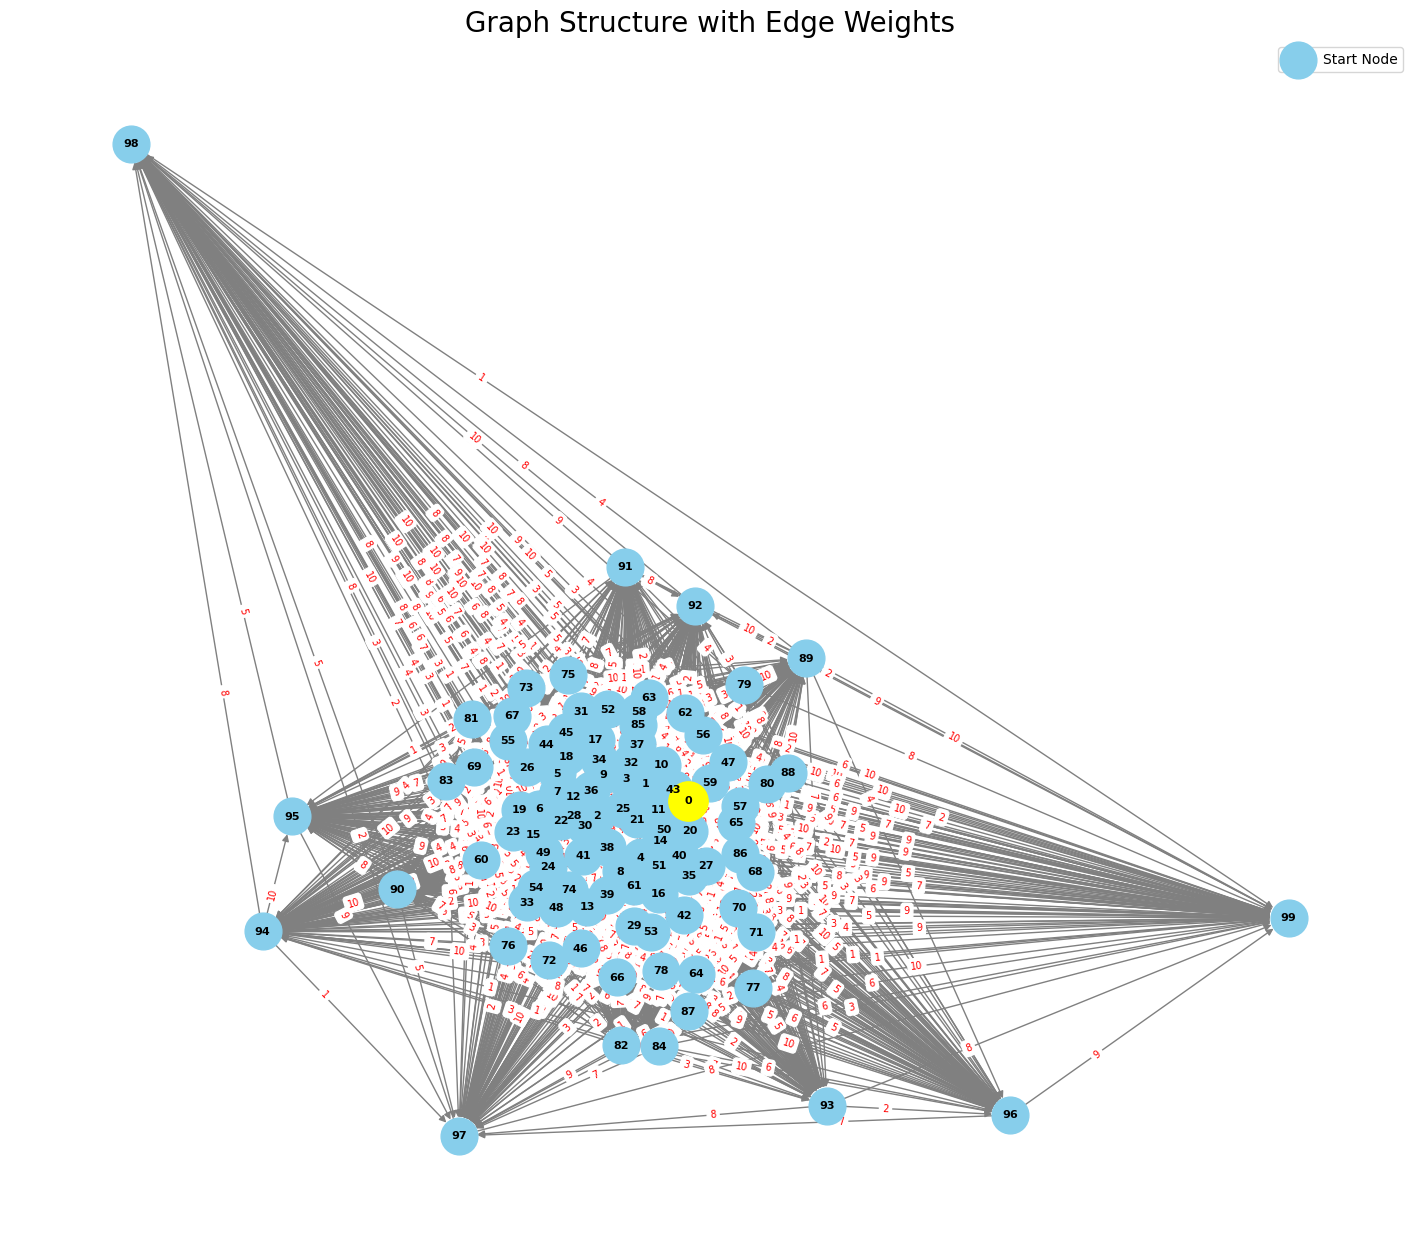

In [56]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
edges = edges_rdd.collect()
for src, (dest, weight) in edges:
    G.add_edge(src, dest, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42, k=0.5)  
plt.figure(figsize=(14, 12))  

nx.draw(G, pos, with_labels=True, node_size=700, node_color="skyblue", font_size=8, font_weight="bold", edge_color="gray")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={(src, dest): f"{weight}" for src, dest, weight in G.edges(data="weight")},
    font_color="red", font_size=7, label_pos=0.3  # Adjust `label_pos` to position labels closer to the start of edges
)

nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color="yellow", node_size=800, label="Start Node (0)")

plt.title("Graph Structure with Edge Weights", fontsize=20)
plt.legend(["Start Node"], loc="upper right", fontsize=10)
plt.show()


---

## Part 3: Implement and Analyze PageRank Algorithm

In Part 3, I implemented the PageRank algorithm to analyze the page network in question3.txt. and I need to identify nodes with the highest and lowest PageRank.


In [153]:
# !python3 code_3.py
# !head question3.txt

In [162]:
spark.stop()
!pkill -f ngrok

In [163]:
# !pip install pyspark pyngrok
# !ngrok config add-authtoken <NGROK_AUTH_TOKEN>


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [164]:
from pyspark.sql import SparkSession

# Start a new Spark session
spark = SparkSession.builder.appName("PageRankAnalysis").getOrCreate()
sc = spark.sparkContext

In [165]:

from pyngrok import ngrok

public_url = ngrok.connect(4040)
print("Spark WebUI Link:", public_url)

Spark WebUI Link: NgrokTunnel: "https://5637-34-138-205-238.ngrok-free.app" -> "http://localhost:4040"


Each node’s out-links are listed here, which represent the connections in the network. This setup is needed for calculating the rank of each node based on its connections

Since question3.txt had a unique format, I adapted the parsing process to separate each source and its destinations.

In [166]:
# Load the adjacency list and process it for PageRank
edges_rdd = sc.textFile("question3.txt") \
    .map(lambda line: line.strip().split(":")) \
    .filter(lambda parts: len(parts) == 2) \
    .flatMap(lambda parts: [(parts[0].strip(), neighbor.strip()) for neighbor in parts[1].replace("[", "").replace("]", "").split(",")])



I grouped links by source and initialized each node’s rank to 1.0.

In [167]:
# Group by source node to create out-links and then collect as a dictionary for broadcasting
links_rdd = edges_rdd.groupByKey().mapValues(list)
links = dict(links_rdd.collect())
links_broadcast = sc.broadcast(links)

# Initialize each node with a rank of 1.0
ranks_rdd = edges_rdd.flatMap(lambda edge: edge).distinct().map(lambda node: (node, 1.0))

In [152]:

sample_links = list(links.items())[:5]  
print("Sample links (out-links) for nodes:", sample_links)
sample_ranks = ranks_rdd.take(5)  
print("Sample initial ranks for nodes:", sample_ranks)

Sample links (out-links) for nodes: [('0', ['85', '81', '23', '91', '78', '88', '95', '7', '70', '54']), ('1', ['26', '14', '77', '54', '28']), ('4', ['20', '53']), ('8', ['10', '9', '91', '38', '84', '30', '46', '40', '45']), ('9', ['85', '2', '81', '24', '8', '31', '4'])]
Sample initial ranks for nodes: [('0', 1.0), ('91', 1.0), ('88', 1.0), ('70', 1.0), ('54', 1.0)]


I defined a function to compute contributions for each node’s neighbors, then iterated over the PageRank calculation with a damping factor of 0.85.

By adjustable damping factor, I ran the PageRank algorithm to calculate the rank for each node. The damping factor helps balance influence across the network, which is especially useful in cases where there’s a chance of 'random jumps' between nodes

In [168]:

def compute_contributions(node_rank):
    node, rank = node_rank
    neighbors = links_broadcast.value.get(node, [])
    num_neighbors = len(neighbors)

    if num_neighbors > 0:
        for neighbor in neighbors:
            yield (neighbor, rank / num_neighbors)
    else:
 
        yield (node, 0)


num_iterations = 10
damping_factor = 0.85


for i in range(num_iterations):

    contributions_rdd = ranks_rdd.flatMap(compute_contributions)

    ranks_rdd = contributions_rdd.reduceByKey(lambda x, y: x + y) \
        .mapValues(lambda rank: (1 - damping_factor) + damping_factor * rank)

In [141]:

sample_ranks = ranks_rdd.take(5)
print(f"Iteration {i+1} ranks sample:", sample_ranks)

Iteration 10 ranks sample: [('60', 2.395888396182062), ('69', 0.9777619303542282), ('57', 1.0298402720757749), ('70', 0.77769459167584), ('66', 1.3732353599072629)]


In [169]:
ranks_rdd.saveAsTextFile("output_3.txt")


Finally, I identified and displayed the nodes with the highest and lowest PageRank scores. To know which nodes are most influential in the network based on their connections

In [143]:

final_ranks = ranks_rdd.collect()

# Finding the node with the highest and lowest PageRank
max_rank_node = max(final_ranks, key=lambda x: x[1])
min_rank_node = min(final_ranks, key=lambda x: x[1])

# Displaying the results
print(f"Node with the highest PageRank: {max_rank_node[0]} - Rank: {max_rank_node[1]}")
print(f"Node with the lowest PageRank: {min_rank_node[0]} - Rank: {min_rank_node[1]}")


Node with the highest PageRank: 55 - Rank: 3.0285322303525977
Node with the lowest PageRank: 51 - Rank: 0.24093543754031138
